In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
pd.set_option('display.max_columns', None)   # exibe todas as colunas
pd.set_option('display.max_colwidth', 60)    # não trunca o conteúdo
pd.set_option('display.float_format', '{:.2f}'.format)

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


In [2]:
hoteis   = pd.read_csv( 'hoteis.csv')
quartos  = pd.read_csv( 'quartos.csv')
hospedes = pd.read_csv( 'hospedes.csv')
reservas = pd.read_csv( 'reservas.csv')
avals    = pd.read_csv( 'avaliacoes.csv')

print("Bases carregadas!")
print(f"  hoteis:      {hoteis.shape}")
print(f"  quartos:     {quartos.shape}")
print(f"  hospedes:    {hospedes.shape}")
print(f"  reservas:    {reservas.shape}")
print(f"  avaliacoes:  {avals.shape}")

Bases carregadas!
  hoteis:      (5, 6)
  quartos:     (58, 7)
  hospedes:    (402, 8)
  reservas:    (1000, 10)
  avaliacoes:  (685, 8)


In [3]:
# Nulos em cada base — chamadas individuais para cada DataFrame
print("--- hoteis ---")
print(hoteis.isnull().sum()[hoteis.isnull().sum() > 0].to_string() or "Sem nulos")
print()
print("--- quartos ---")
print(quartos.isnull().sum()[quartos.isnull().sum() > 0].to_string() or "Sem nulos")
print()
print("--- hospedes ---")
print(hospedes.isnull().sum()[hospedes.isnull().sum() > 0].to_string() or "Sem nulos")
print()
print("--- reservas ---")
print(reservas.isnull().sum()[reservas.isnull().sum() > 0].to_string() or "Sem nulos")
print()
print("--- avaliacoes ---")
print(avals.isnull().sum()[avals.isnull().sum() > 0].to_string() or "Sem nulos")



--- hoteis ---
n_quartos    1

--- quartos ---
valor_base    4

--- hospedes ---
cidade_origem    1
estado           1
genero           1

--- reservas ---
canal_reserva    5
valor_diaria     3

--- avaliacoes ---
nota_limpeza         4
nota_atendimento     2
comentario          53


In [4]:
# Com apenas 5 linhas, visualizamos tudo de uma vez
print(hoteis.to_string())


   id_hotel           nome_hotel          cidade estado   categoria  n_quartos
0         1       Nara Fortaleza       Fortaleza     CE  5 estrelas     120.00
1         2          Nara Recife          Recife     PE  4 estrelas      95.00
2         3        Nara Salvador        Salvador     BA  4 estrelas        NaN
3         4  Nara Rio de Janeiro  Rio De Janeiro     RJ  3 estrelas      80.00
4         5       Nara São Paulo       Sao Paulo     SP  6 estrelas     150.00


In [5]:
# Valores únicos de categoria
print(hoteis['categoria'].value_counts())

categoria
4 estrelas    2
5 estrelas    1
3 estrelas    1
6 estrelas    1
Name: count, dtype: int64


In [6]:
dominios_validos = ['3 estrelas', '4 estrelas', '5 estrelas']

# Identificar registros fora do domínio
print("Categorias inválidas:")
print(hoteis.loc[~hoteis['categoria'].isin(dominios_validos), ['id_hotel', 'nome_hotel', 'categoria']])

# Corrigir
hoteis.loc[~hoteis['categoria'].isin(dominios_validos), 'categoria'] = '5 estrelas'
print("\nCategorias após correção:")
print(hoteis['categoria'].value_counts())



Categorias inválidas:
   id_hotel      nome_hotel   categoria
4         5  Nara São Paulo  6 estrelas

Categorias após correção:
categoria
5 estrelas    2
4 estrelas    2
3 estrelas    1
Name: count, dtype: int64


In [7]:
# Contar quartos por hotel em quartos.csv
quartos_por_hotel = (
    quartos
    .groupby('id_hotel')['id_quarto']   # agrupa por hotel e seleciona a coluna id_quarto
    .count()                            # conta quantos quartos cada hotel tem
    .reset_index()                      # transforma o índice em coluna
    .rename(columns={'id_quarto': 'n_quartos'})
)
print(quartos_por_hotel)


   id_hotel  n_quartos
0         1         12
1         2         11
2         3         11
3         4         10
4         5         13
5         9          1


In [8]:
# Cruzar com hoteis para preencher o nulo

# Remover a coluna auxiliar que usamos só para o preenchimento
hoteis = hoteis.drop(columns=['n_quartos'])

# merge() une as duas bases pelo id_hotel
hoteis = hoteis.merge(quartos_por_hotel, on='id_hotel', how='left')


print(hoteis[['id_hotel', 'nome_hotel', 'n_quartos']])
#SUBSTITUIR TODOS OS DADOS DE N QUARTOS

   id_hotel           nome_hotel  n_quartos
0         1       Nara Fortaleza         12
1         2          Nara Recife         11
2         3        Nara Salvador         11
3         4  Nara Rio de Janeiro         10
4         5       Nara São Paulo         13


In [9]:
hoteis['cidade'] = (
    hoteis['cidade']
    .str.strip()      # remove espaços nas bordas
    .str.title()      # capitaliza a primeira letra de cada palavra
    .replace({
        'Sao Paulo':      'São Paulo',       # acento ausente
        'Rio De Janeiro': 'Rio de Janeiro',  # preposição 'de' em minúsculo
    })
)

print(hoteis[['id_hotel', 'nome_hotel', 'cidade', 'estado']])




   id_hotel           nome_hotel          cidade estado
0         1       Nara Fortaleza       Fortaleza     CE
1         2          Nara Recife          Recife     PE
2         3        Nara Salvador        Salvador     BA
3         4  Nara Rio de Janeiro  Rio de Janeiro     RJ
4         5       Nara São Paulo       São Paulo     SP


In [10]:
print("hoteis — situação final:")
print(f"  Linhas: {len(hoteis)}")
print(hoteis.isnull().sum())

hoteis — situação final:
  Linhas: 5
id_hotel      0
nome_hotel    0
cidade        0
estado        0
categoria     0
n_quartos     0
dtype: int64


In [11]:
print(quartos.dtypes)
print()
print("Nulos por coluna:")
print(quartos.isnull().sum())


id_quarto          str
id_hotel         int64
tipo_quarto        str
capacidade       int64
valor_base     float64
andar            int64
vista              str
dtype: object

Nulos por coluna:
id_quarto      0
id_hotel       0
tipo_quarto    0
capacidade     0
valor_base     4
andar          0
vista          0
dtype: int64


In [12]:
# Grafias em tipo_quarto
print("Valores únicos em tipo_quarto:")
print(quartos['tipo_quarto'].value_counts())



Valores únicos em tipo_quarto:
tipo_quarto
Standard        12
Luxo            11
Superior        10
Suite            9
Suite Master     5
Standart         2
STANDARD         2
superior         2
standard         2
SUPERIOR         2
STANDART         1
Name: count, dtype: int64


In [13]:
# Capacidades inválidas
print("Capacidades <= 0:")
print(quartos.loc[quartos['capacidade'] <= 0, ['id_quarto', 'id_hotel', 'tipo_quarto', 'capacidade']])


Capacidades <= 0:
   id_quarto  id_hotel tipo_quarto  capacidade
9       Q010         1       Suite           0
10      Q011         1       Suite          -1
53      Q054         5        Luxo          -2


In [14]:
# Quarto com id_hotel inexistente
ids_hoteis_validos = hoteis['id_hotel'].tolist()
print("Quartos com id_hotel sem correspondência em hoteis.csv:")
print(quartos.loc[~quartos['id_hotel'].isin(ids_hoteis_validos), ['id_quarto', 'id_hotel', 'tipo_quarto']])


Quartos com id_hotel sem correspondência em hoteis.csv:
   id_quarto  id_hotel tipo_quarto
57      Q058         9    Standard


In [15]:
# Padronizar tipo_quarto em 3 passos encadeados
correcoes_tipo = {'standart': 'standard'}  # erros de digitação conhecidos

quartos['tipo_quarto'] = (
    quartos['tipo_quarto']
    .str.strip()               # remove espaços
    .str.lower()               # tudo minúsculo → elimina diferenças de caixa
    .replace(correcoes_tipo)   # corrige erros de digitação
    .str.title()               # capitalização padrão
)

print("Tipos após padronização:")
print(quartos['tipo_quarto'].value_counts())


Tipos após padronização:
tipo_quarto
Standard        19
Superior        14
Luxo            11
Suite            9
Suite Master     5
Name: count, dtype: int64


In [16]:
# Calcular a mediana de capacidade por tipo de quarto (só dos válidos)
mediana_cap = (
    quartos[quartos['capacidade'] > 0]          # usa só registros válidos no cálculo
    .groupby('tipo_quarto')['capacidade']
    .transform('median')                        # devolve o valor no índice original
)

# Onde capacidade é 0, substituir pela mediana do tipo
mask_zero = quartos['capacidade'] == 0
quartos.loc[mask_zero, 'capacidade'] = mediana_cap[mask_zero]

print(f"Registros corrigidos (capacidade 0): {mask_zero.sum()}")
''

Registros corrigidos (capacidade 0): 1


''

In [17]:
# Remover capacidades negativas
antes = len(quartos)
quartos = quartos[quartos['capacidade'] > 0].copy()
print(f"Removidos (capacidade negativa): {antes - len(quartos)}")

Removidos (capacidade negativa): 3


In [18]:
# Calcular mediana de valor_base por hotel + tipo de quarto
mediana_valor = (
    quartos
    .groupby(['id_hotel', 'tipo_quarto'])['valor_base']
    .transform('median')
)

# fillna() preenche só onde o valor é nulo
quartos['valor_base'] = quartos['valor_base'].fillna(mediana_valor)

print(f"Nulos restantes em valor_base: {quartos['valor_base'].isnull().sum()}")


Nulos restantes em valor_base: 0


In [19]:
# Remover quarto com id_hotel inexistente
antes = len(quartos)
quartos = quartos[quartos['id_hotel'].isin(ids_hoteis_validos)].copy()
print(f"Removidos (id_hotel inválido): {antes - len(quartos)}")


Removidos (id_hotel inválido): 1


In [20]:
print("quartos — situação final:")
print(f"  Linhas: {len(quartos)}")
print(quartos.isnull().sum())


quartos — situação final:
  Linhas: 54
id_quarto      0
id_hotel       0
tipo_quarto    0
capacidade     0
valor_base     0
andar          0
vista          0
dtype: int64


In [21]:
quartos['id_quarto'] = quartos['id_quarto'].str[1:]
quartos

,id_quarto,id_hotel,tipo_quarto,capacidade,valor_base,andar,vista
0,001,1,Standard,2.00,320.00,1,Jardim
1,002,1,Standard,2.00,320.00,2,Jardim
2,003,1,Standard,2.00,320.00,3,Jardim
3,004,1,Standard,2.00,320.00,4,Jardim
4,005,1,Superior,3.00,480.00,5,Mar
5,006,1,Superior,3.00,480.00,6,Mar
6,007,1,Superior,3.00,480.00,7,Mar
7,008,1,Luxo,4.00,750.00,8,Mar
8,009,1,Luxo,4.00,750.00,9,Mar
11,012,1,Suite Master,6.00,2200.00,12,Panorâmica


In [22]:
print(hospedes.dtypes)
print()
print("Nulos por coluna:")
print(hospedes.isnull().sum())


id_hospede         int64
nome                 str
email                str
telefone             str
cidade_origem        str
estado               str
data_nascimento      str
genero               str
dtype: object

Nulos por coluna:
id_hospede         0
nome               0
email              0
telefone           0
cidade_origem      1
estado             1
data_nascimento    0
genero             1
dtype: int64


In [23]:
# E-mails sem '@'
print("E-mails sem '@':")
print(hospedes.loc[~hospedes['email'].str.contains('@', na=False), ['id_hospede', 'nome', 'email']])


E-mails sem '@':
    id_hospede               nome                   email
4            5  Cristina Ferreira  carlossilva.semdominio
11          12       Daniel Souza   emailsemarrobasemnada


In [24]:
# IDs duplicados
# duplicated(keep=False) marca TODOS os duplicados, inclusive o primeiro
print("IDs duplicados:")
print(hospedes.loc[hospedes.duplicated('id_hospede', keep=False), ['id_hospede', 'nome', 'email']])


IDs duplicados:
     id_hospede           nome                        email
49           50  Rodrigo Alves   rodrigo.alves3@hotmail.com
99          100  Bruno Pereira  bruno.pereira61@outlook.com
400          50  Rodrigo Alves   rodrigo.alves3@hotmail.com
401         100  Bruno Pereira  bruno.pereira61@outlook.com


In [25]:
print("Valores únicos em 'estado':")
print(hospedes['estado'].value_counts(dropna=False))


Valores únicos em 'estado':
estado
MG                44
DF                43
AM                42
SP                41
RS                41
PR                40
CE                37
PE                37
BA                37
RJ                36
rio de janeiro     1
NaN                1
Sp                 1
RRJ                1
Name: count, dtype: int64


In [26]:
print("Valores únicos em 'genero':")
print(hospedes['genero'].value_counts(dropna=False))


Valores únicos em 'genero':
genero
F            200
M            199
Masculino      1
fem            1
NaN            1
Name: count, dtype: int64


In [27]:
# Datas de nascimento: converter e verificar limites
hospedes['data_nascimento'] = pd.to_datetime(hospedes['data_nascimento'], errors='coerce')

limite_inf = pd.Timestamp('1920-01-01')
limite_sup = pd.Timestamp('2007-01-01')

mask_data_inv = (
    hospedes['data_nascimento'].notna() &
    ((hospedes['data_nascimento'] < limite_inf) | (hospedes['data_nascimento'] > limite_sup))
)
print(f"Datas suspeitas: {mask_data_inv.sum()}")
print(hospedes.loc[mask_data_inv, ['id_hospede', 'nome', 'data_nascimento']])


Datas suspeitas: 2
    id_hospede              nome data_nascimento
19          20     Leonardo Dias      1899-03-15
54          55  Carolina Ribeiro      2020-06-10


In [28]:
# Padrão mínimo de e-mail: algo@algo.algo
# ^ = início, $ = fim, [^@]+ = um ou mais caracteres que não sejam @
padrao_email = r'^[^@]+@[^@]+\.[^@]+$'

# str.contains() retorna True onde o padrão bate
email_valido = hospedes['email'].str.contains(padrao_email, na=False)

print(f"E-mails inválidos encontrados: {(~email_valido).sum()}")

# Onde o e-mail é inválido, substituir por nulo
hospedes.loc[~email_valido, 'email'] = None
print(f"Nulos em email após correção: {hospedes['email'].isnull().sum()}")


E-mails inválidos encontrados: 3
Nulos em email após correção: 3


In [29]:
# Remover tudo que não for dígito
hospedes['telefone'] = hospedes['telefone'].str.replace(r'\D', '', regex=True)

# Calcular o comprimento de cada telefone
tamanho = hospedes['telefone'].str.len()

# Marcar como nulo onde o comprimento não é 10 nem 11
hospedes.loc[~tamanho.isin([10, 11]), 'telefone'] = None

print(f"Telefones válidos: {hospedes['telefone'].notnull().sum()}")
print(f"Telefones nulos:   {hospedes['telefone'].isnull().sum()}")


Telefones válidos: 400
Telefones nulos:   2


In [30]:
hospedes['nome'] = hospedes['nome'].str.strip().str.title()

print("Amostra após padronização:")
print(hospedes['nome'].head(8).to_string())


Amostra após padronização:
0       Carlos Pereira
1          Diego Alves
2        Bruno Ribeiro
3       Sandra Pereira
4    Cristina Ferreira
5     Mariana Carvalho
6          Amanda Dias
7        Paulo Martins


In [31]:
# Dicionário completo: variações → sigla oficial
mapa_estado = {
    # Siglas já corretas
    'AC': 'AC', 'AL': 'AL', 'AP': 'AP', 'AM': 'AM', 'BA': 'BA',
    'CE': 'CE', 'DF': 'DF', 'ES': 'ES', 'GO': 'GO', 'MA': 'MA',
    'MT': 'MT', 'MS': 'MS', 'MG': 'MG', 'PA': 'PA', 'PB': 'PB',
    'PR': 'PR', 'PE': 'PE', 'PI': 'PI', 'RJ': 'RJ', 'RN': 'RN',
    'RS': 'RS', 'RO': 'RO', 'RR': 'RR', 'SC': 'SC', 'SP': 'SP',
    'SE': 'SE', 'TO': 'TO',
    # Variações incorretas
    'rj': 'RJ', 'rio de janeiro': 'RJ',
    'sp': 'SP', 'sao paulo': 'SP', 'são paulo': 'SP',
    'mg': 'MG', 'ba': 'BA', 'ce': 'CE',
}

# Normalizar e mapear
# .str.lower() garante que bata com as chaves do dicionário (todas em minúsculo)
hospedes['estado'] = (
    hospedes['estado']
    .str.strip()
    .str.lower()
    .map(mapa_estado)   # o que não estiver no dicionário vira NaN
)

print("Estados após normalização:")
print(hospedes['estado'].value_counts(dropna=False))


Estados após normalização:
estado
NaN    205
MG      44
SP      42
RJ      37
CE      37
BA      37
Name: count, dtype: int64


In [32]:
# Datas inválidas → nulo
# mask_data_inv já foi calculada na inspeção
hospedes.loc[mask_data_inv, 'data_nascimento'] = None
print(f"Datas invalidadas: {mask_data_inv.sum()}")


Datas invalidadas: 2


In [33]:
# Gênero: map() com dicionário — o que não está vira NaN
mapa_genero = {
    'm': 'M', 'masculino': 'M', 'masc': 'M',
    'f': 'F', 'feminino':  'F', 'fem':  'F',
}

hospedes['genero'] = (
    hospedes['genero']
    .str.strip()
    .str.lower()
    .map(mapa_genero)
)

print("Gênero após padronização:")
print(hospedes['genero'].value_counts(dropna=False))


Gênero após padronização:
genero
F      201
M      200
NaN      1
Name: count, dtype: int64


In [34]:
# Remover IDs duplicados — manter primeira ocorrência
antes = len(hospedes)
hospedes = hospedes.drop_duplicates(subset='id_hospede', keep='first').copy()
print(f"Removidos (ID duplicado): {antes - len(hospedes)}")


Removidos (ID duplicado): 2


In [35]:
print("hospedes — situação final:")
print(f"  Linhas: {len(hospedes)}")
print(hospedes.isnull().sum())


hospedes — situação final:
  Linhas: 400
id_hospede           0
nome                 0
email                3
telefone             2
cidade_origem        1
estado             204
data_nascimento      3
genero               1
dtype: int64


In [36]:
print(reservas.dtypes)
print()
print("Nulos por coluna:")
print(reservas.isnull().sum())

id_reserva          int64
id_hospede          int64
id_quarto             str
id_hotel            int64
data_checkin          str
data_checkout         str
canal_reserva         str
valor_diaria      float64
status_reserva        str
data_reserva          str
dtype: object

Nulos por coluna:
id_reserva        0
id_hospede        0
id_quarto         0
id_hotel          0
data_checkin      0
data_checkout     0
canal_reserva     5
valor_diaria      3
status_reserva    0
data_reserva      0
dtype: int64


In [37]:
# Converter colunas de data
# errors='coerce' transforma valores impossíveis em NaT em vez de levantar erro
reservas['data_checkin']  = pd.to_datetime(reservas['data_checkin'],  errors='coerce')
reservas['data_checkout'] = pd.to_datetime(reservas['data_checkout'], errors='coerce')
reservas['data_reserva']  = pd.to_datetime(reservas['data_reserva'],  errors='coerce')

# Checkout inválido
print(f"Checkout anterior ou igual ao checkin: {(reservas['data_checkout'] <= reservas['data_checkin']).sum()}")


Checkout anterior ou igual ao checkin: 5


In [38]:
# Estatísticas do valor da diária
print(reservas['valor_diaria'].describe())
print(f"\nValores negativos: {(reservas['valor_diaria'] < 0).sum()}")
print(f"Valores zero:      {(reservas['valor_diaria'] == 0).sum()}")
print(f"Valores nulos:     {reservas['valor_diaria'].isnull().sum()}")


count     997.00
mean     1615.29
std      1551.61
min      -274.84
25%       895.60
50%      1528.24
75%      2138.14
max     24637.28
Name: valor_diaria, dtype: float64

Valores negativos: 3
Valores zero:      1
Valores nulos:     3


In [39]:
print("Valores em status_reserva:")
print(reservas['status_reserva'].value_counts(dropna=False))

Valores em status_reserva:
status_reserva
Confirmada     965
Overbooking     18
Cancelado        7
No-show          4
no-show          2
CONFIRMADA       2
confirmada       1
Cancelada        1
Name: count, dtype: int64


In [40]:
print("Valores em canal_reserva:")
print(reservas['canal_reserva'].value_counts(dropna=False))


Valores em canal_reserva:
canal_reserva
Expedia              220
Booking.com          205
Site Próprio         203
Telefone             179
Agência de Viagem    176
EXPEDIA                5
NaN                    5
site próprio           3
Agencia de Viagem      2
booking.com            2
Name: count, dtype: int64


In [41]:
reservas['id_quarto'] = reservas['id_quarto'].astype(str).str[1:]
reservas

,id_reserva,id_hospede,id_quarto,id_hotel,data_checkin,data_checkout,canal_reserva,valor_diaria,status_reserva,data_reserva
0,1,203,026,3,2024-10-28,2024-10-29,Site Próprio,2344.25,Confirmada,2024-10-21
1,2,30,033,3,2024-06-03,2024-06-07,Site Próprio,469.17,Confirmada,2024-05-07
2,3,47,004,1,2024-07-18,2024-07-25,Site Próprio,2358.47,Confirmada,2024-07-10
3,4,322,023,2,2024-08-19,2024-08-20,Telefone,1743.13,Confirmada,2024-08-15
4,5,286,013,2,2023-05-17,2023-05-22,Agência de Viagem,617.85,Confirmada,2023-05-09
...,...,...,...,...,...,...,...,...,...,...
995,996,114,021,2,2024-10-15,2024-10-17,Site Próprio,1659.53,Confirmada,2024-09-06
996,997,71,046,5,2023-10-24,2023-11-07,Agência de Viagem,1374.80,Confirmada,2023-09-16
997,998,25,018,2,2024-07-30,2024-08-11,Site Próprio,1634.99,Confirmada,2024-06-17
998,999,306,039,4,2023-03-01,2023-03-15,Site Próprio,506.11,Confirmada,2023-02-24


In [42]:
# id_hospede sem correspondência
ids_hospedes_validos = hospedes['id_hospede'].tolist()
print(f"Reservas com id_hospede inválido: {(~reservas['id_hospede'].isin(ids_hospedes_validos)).sum()}")

# data_reserva posterior ao checkin
print(f"data_reserva posterior ao checkin: {(reservas['data_reserva'] > reservas['data_checkin']).sum()}")


Reservas com id_hospede inválido: 5
data_reserva posterior ao checkin: 4


In [43]:
# 1. Checkout inválido
antes = len(reservas)
reservas = reservas[reservas['data_checkout'] > reservas['data_checkin']].copy()
print(f"Removidos (checkout inválido): {antes - len(reservas)}")


Removidos (checkout inválido): 5


In [44]:
# 2. Diárias inválidas — negativas, zero e nulas em uma só etapa
antes = len(reservas)
reservas = reservas[reservas['valor_diaria'].notna() & (reservas['valor_diaria'] > 0)].copy()
print(f"Removidos (diária inválida): {antes - len(reservas)}")


Removidos (diária inválida): 7


In [45]:
# 3. Padronizar status_reserva com map()
mapa_status = {
    'confirmada':  'Confirmada',  'Confirmada': 'Confirmada', 'CONFIRMADA': 'Confirmada',
    'cancelada':   'Cancelada',   'Cancelada':  'Cancelada',  'Cancelado':  'Cancelada',
    'no-show':     'No-show',     'No-show':    'No-show',    'NO-SHOW':    'No-show',
    'overbooking': 'Overbooking', 'Overbooking':'Overbooking',
}
reservas['status_reserva'] = reservas['status_reserva'].map(mapa_status)

print("Status após padronização:")
print(reservas['status_reserva'].value_counts(dropna=False))


Status após padronização:
status_reserva
Confirmada     956
Overbooking     18
Cancelada        8
No-show          6
Name: count, dtype: int64


In [46]:
# 4. Padronizar canal_reserva
mapa_canal = {
    'Site Próprio': 'Site Próprio',  'site próprio':      'Site Próprio',
    'Booking.com':  'Booking.com',   'booking.com':       'Booking.com',
    'Expedia':      'Expedia',       'EXPEDIA':            'Expedia',
    'Agência de Viagem': 'Agência de Viagem',
    'Agencia de Viagem': 'Agência de Viagem',
    'Telefone':     'Telefone',
}
reservas['canal_reserva'] = reservas['canal_reserva'].map(mapa_canal)

# 5. Canal nulo → 'Não informado'
reservas['canal_reserva'] = reservas['canal_reserva'].fillna('Não informado')

print("Canal após padronização:")
print(reservas['canal_reserva'].value_counts(dropna=False))


Canal após padronização:
canal_reserva
Expedia              224
Site Próprio         204
Booking.com          202
Telefone             177
Agência de Viagem    176
Não informado          5
Name: count, dtype: int64


In [47]:
# 6. Remover id_hospede inexistente
antes = len(reservas)
reservas = reservas[reservas['id_hospede'].isin(ids_hospedes_validos)].copy()
print(f"Removidos (id_hospede inválido): {antes - len(reservas)}")

Removidos (id_hospede inválido): 5


In [48]:
# 7. Remover data_reserva posterior ao checkin
antes = len(reservas)
reservas = reservas[reservas['data_reserva'] <= reservas['data_checkin']].copy()
print(f"Removidos (data_reserva inválida): {antes - len(reservas)}")


Removidos (data_reserva inválida): 4


In [49]:
print("reservas — situação final:")
print(f"  Linhas: {len(reservas)}")
print()
print(reservas.isnull().sum())
print()
print(reservas['status_reserva'].value_counts())


reservas — situação final:
  Linhas: 979

id_reserva        0
id_hospede        0
id_quarto         0
id_hotel          0
data_checkin      0
data_checkout     0
canal_reserva     0
valor_diaria      0
status_reserva    0
data_reserva      0
dtype: int64

status_reserva
Confirmada     947
Overbooking     18
Cancelada        8
No-show          6
Name: count, dtype: int64


In [50]:
print(avals.dtypes)
print()
print("Nulos por coluna:")
print(avals.isnull().sum())

id_avaliacao              int64
id_reserva                int64
nota_geral                  str
nota_limpeza            float64
nota_atendimento        float64
nota_custo_beneficio        str
comentario                  str
data_avaliacao              str
dtype: object

Nulos por coluna:
id_avaliacao             0
id_reserva               0
nota_geral               0
nota_limpeza             4
nota_atendimento         2
nota_custo_beneficio     0
comentario              53
data_avaliacao           0
dtype: int64


In [51]:
# Converter colunas de nota para numérico
# errors='coerce' transforma valores como 'ótimo' ou '9,0' em NaN
avals['nota_geral']            = pd.to_numeric(avals['nota_geral'],            errors='coerce')
avals['nota_limpeza']          = pd.to_numeric(avals['nota_limpeza'],          errors='coerce')
avals['nota_atendimento']      = pd.to_numeric(avals['nota_atendimento'],      errors='coerce')
avals['nota_custo_beneficio']  = pd.to_numeric(avals['nota_custo_beneficio'],  errors='coerce')

print("Tipos após conversão:")
print(avals[['nota_geral','nota_limpeza','nota_atendimento','nota_custo_beneficio']].dtypes)


Tipos após conversão:
nota_geral              float64
nota_limpeza            float64
nota_atendimento        float64
nota_custo_beneficio    float64
dtype: object


In [52]:
# Notas fora do range 0–10
# between(0, 10) retorna True para valores dentro do intervalo
fora_geral   = avals['nota_geral'].notna()           & ~avals['nota_geral'].between(0, 10)
fora_limp    = avals['nota_limpeza'].notna()          & ~avals['nota_limpeza'].between(0, 10)
fora_atend   = avals['nota_atendimento'].notna()      & ~avals['nota_atendimento'].between(0, 10)
fora_cb      = avals['nota_custo_beneficio'].notna()  & ~avals['nota_custo_beneficio'].between(0, 10)

print(f"nota_geral fora do range:           {fora_geral.sum()}")
print(f"nota_limpeza fora do range:         {fora_limp.sum()}")
print(f"nota_atendimento fora do range:     {fora_atend.sum()}")
print(f"nota_custo_beneficio fora do range: {fora_cb.sum()}")


nota_geral fora do range:           3
nota_limpeza fora do range:         4
nota_atendimento fora do range:     3
nota_custo_beneficio fora do range: 0


In [53]:
# Converter data_avaliacao
avals['data_avaliacao'] = pd.to_datetime(avals['data_avaliacao'], errors='coerce')

# Cruzar com reservas para verificar coerência de datas e status
# merge() com how='left' mantém todas as linhas de avals
avals_check = avals.merge(
    reservas[['id_reserva', 'data_checkout', 'status_reserva']],
    on='id_reserva',
    how='left'
)

print(f"Avaliações com data anterior ao checkout: {(avals_check['data_avaliacao'] < avals_check['data_checkout']).sum()}")
print(f"Avaliações de reservas canceladas/no-show: {avals_check['status_reserva'].isin(['Cancelada','No-show']).sum()}")


Avaliações com data anterior ao checkout: 4
Avaliações de reservas canceladas/no-show: 8


In [54]:
# Remover registros com nota_geral fora do domínio (inclui os que viraram NaN)
antes = len(avals)
avals = avals[avals['nota_geral'].notna() & avals['nota_geral'].between(0, 10)].copy()
print(f"Removidos (nota_geral inválida): {antes - len(avals)}")


Removidos (nota_geral inválida): 6


In [55]:
# Invalidar campos secundários com valor fora do range
# Substituímos só o campo — o registro permanece
fora_limp   = avals['nota_limpeza'].notna()         & ~avals['nota_limpeza'].between(0, 10)
fora_atend  = avals['nota_atendimento'].notna()     & ~avals['nota_atendimento'].between(0, 10)
fora_cb     = avals['nota_custo_beneficio'].notna() & ~avals['nota_custo_beneficio'].between(0, 10)

avals.loc[fora_limp,  'nota_limpeza']          = None
avals.loc[fora_atend, 'nota_atendimento']      = None
avals.loc[fora_cb,    'nota_custo_beneficio']  = None

print(f"nota_limpeza invalidadas:          {fora_limp.sum()}")
print(f"nota_atendimento invalidadas:      {fora_atend.sum()}")
print(f"nota_custo_beneficio invalidadas:  {fora_cb.sum()}")


nota_limpeza invalidadas:          4
nota_atendimento invalidadas:      3
nota_custo_beneficio invalidadas:  0


In [56]:
# Cruzar avaliações com reservas para obter data_checkout e status
avals = avals.merge(
    reservas[['id_reserva', 'data_checkout', 'status_reserva']],
    on='id_reserva',
    how='left'
)

# Remover avaliações com data anterior ao checkout
antes = len(avals)
avals = avals[
    avals['data_avaliacao'].isna() |              # mantém os que não têm data (NaT)
    (avals['data_avaliacao'] >= avals['data_checkout'])  # ou que são posteriores ao checkout
].copy()
print(f"Removidos (avaliação antes do checkout): {antes - len(avals)}")


Removidos (avaliação antes do checkout): 19


In [57]:
# Remover avaliações de reservas canceladas ou no-show
antes = len(avals)
avals = avals[~avals['status_reserva'].isin(['Cancelada', 'No-show'])].copy()
print(f"Removidos (reserva cancelada/no-show): {antes - len(avals)}")

# Remover colunas auxiliares que vieram do merge
avals = avals.drop(columns=['data_checkout', 'status_reserva'])


Removidos (reserva cancelada/no-show): 8


In [58]:
print("avaliacoes — situação final:")
print(f"  Linhas: {len(avals)}")
print()
print(avals.isnull().sum())

avaliacoes — situação final:
  Linhas: 652

id_avaliacao             0
id_reserva               0
nota_geral               0
nota_limpeza             8
nota_atendimento         5
nota_custo_beneficio     2
comentario              52
data_avaliacao           0
dtype: int64


In [59]:
# Resumo comparativo
print(f"{'BASE':<22} {'ORIGINAL':>10} {'TRATADO':>10} {'REMOVIDOS':>12}")
print("-" * 56)
print(f"{'hoteis.csv':<22}       {5:>5}    {len(hoteis):>5}    {5 - len(hoteis):>5}")
print(f"{'quartos.csv':<22}      {58:>5}    {len(quartos):>5}    {58 - len(quartos):>5}")
print(f"{'hospedes.csv':<22}    {402:>5}    {len(hospedes):>5}    {402 - len(hospedes):>5}")
print(f"{'reservas.csv':<22}   {1000:>5}    {len(reservas):>5}    {1000 - len(reservas):>5}")
print(f"{'avaliacoes.csv':<22}  {685:>5}    {len(avals):>5}    {685 - len(avals):>5}")


BASE                     ORIGINAL    TRATADO    REMOVIDOS
--------------------------------------------------------
hoteis.csv                       5        5        0
quartos.csv                    58       54        4
hospedes.csv                402      400        2
reservas.csv              1000      979       21
avaliacoes.csv            685      652       33


In [60]:
OUTPUT = './'

hoteis.to_csv(OUTPUT + 'hoteis_tratado.csv',
              index=False, encoding='utf-8', sep=';', decimal=',')

quartos.to_csv(OUTPUT + 'quartos_tratado.csv',
               index=False, encoding='utf-8', sep=';', decimal=',')

hospedes.to_csv(OUTPUT + 'hospedes_tratado.csv',
                index=False, encoding='utf-8', sep=';', decimal=',')

reservas.to_csv(OUTPUT + 'reservas_tratado.csv',
                index=False, encoding='utf-8', sep=';', decimal=',')

avals.to_csv(OUTPUT + 'avaliacoes_tratado.csv',
             index=False, encoding='utf-8', sep=';', decimal=',')

print("Bases tratadas salvas com sucesso!")
print("Próxima etapa: análise estatística e painel de visualização.")


Bases tratadas salvas com sucesso!
Próxima etapa: análise estatística e painel de visualização.


In [61]:
array_valor_diaria = np.array(reservas['valor_diaria'])

# Quartis
q1 = np.percentile(array_valor_diaria, 25)
q2 = np.percentile(array_valor_diaria, 50)
q3 = np.percentile(array_valor_diaria, 75)

# IQR
iqr = q3 - q1

# Limites
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

# Estatísticas
media = np.mean(array_valor_diaria)
mediana = np.median(array_valor_diaria)
distancia = (media - mediana) / mediana

# Prints (igual seu modelo)
print(f'Primeiro quartil (Q1): {q1}')
print(f'Segundo quartil (Q2, Mediana): {q2}')
print(f'Terceiro quartil (Q3): {q3}')

print(f'O valor da média é: {media}')
print(f'O valor da mediana é: {mediana}')
print(f'A distância entre a média e a mediana é: {distancia}')

print(f'O limite superior é: {limite_superior}')
print(f'O limite inferior é: {limite_inferior}')

Primeiro quartil (Q1): 899.835
Segundo quartil (Q2, Mediana): 1544.67
Terceiro quartil (Q3): 2140.5299999999997
O valor da média é: 1623.4479162410626
O valor da mediana é: 1544.67
A distância entre a média e a mediana é: 0.05099983571964399
O limite superior é: 4001.5724999999993
O limite inferior é: -961.2074999999995


In [62]:
outliers_valor_diaria = reservas.loc[
    reservas['valor_diaria'] >= limite_superior
]

outliers_valor_diaria = outliers_valor_diaria.sort_values(
    by='valor_diaria',
    ascending=False
)

print(outliers_valor_diaria)

     id_reserva  id_hospede id_quarto  id_hotel data_checkin data_checkout  \
511         512          57       025         3   2023-05-04    2023-05-12   
33           34         144       001         1   2024-04-28    2024-05-03   
177         178         130       057         5   2023-06-12    2023-06-18   
320         321         213       039         4   2023-06-16    2023-06-17   
688         689         354       043         4   2024-10-08    2024-10-10   

     canal_reserva  valor_diaria status_reserva data_reserva  
511    Booking.com      24637.28     Confirmada   2023-05-03  
33     Booking.com      23785.17     Confirmada   2024-04-05  
177       Telefone      19486.09     Confirmada   2023-04-20  
320        Expedia      19122.22     Confirmada   2023-05-06  
688  Não informado      16283.31     Confirmada   2024-08-20  


In [63]:
df_menor_q1 = reservas.loc[
    reservas['valor_diaria'] < q1
]

df_menor_q1 = df_menor_q1.sort_values(
    by='valor_diaria',
    ascending=False
)

print(df_menor_q1)

     id_reserva  id_hospede id_quarto  id_hotel data_checkin data_checkout  \
458         459         309       050         5   2023-04-26    2023-04-27   
783         784          88       012         1   2023-06-04    2023-06-18   
729         730         300       014         2   2024-04-08    2024-04-21   
533         534         190       022         2   2024-06-19    2024-06-25   
970         971          81       011         1   2024-12-08    2024-12-13   
..          ...         ...       ...       ...          ...           ...   
930         931          48       002         1   2023-04-04    2023-04-07   
277         278          78       038         4   2024-10-03    2024-10-04   
901         902          59       025         3   2024-01-25    2024-01-27   
684         685         119       006         1   2024-07-11    2024-07-17   
972         973         135       025         3   2024-05-16    2024-05-19   

         canal_reserva  valor_diaria status_reserva data_reserv

In [64]:
array_nota = np.array(avals['nota_geral'])

q1 = np.percentile(array_nota, 25)
q2 = np.percentile(array_nota, 50)
q3 = np.percentile(array_nota, 75)

iqr = q3 - q1

limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

media = np.mean(array_nota)
mediana = np.median(array_nota)
distancia = (media - mediana) / mediana

print(f'\n--- NOTA GERAL ---')
print(f'Q1: {q1}')
print(f'Q2: {q2}')
print(f'Q3: {q3}')
print(f'Média: {media}')
print(f'Mediana: {mediana}')
print(f'Distância: {distancia}')
print(f'Limite superior: {limite_superior}')
print(f'Limite inferior: {limite_inferior}')


--- NOTA GERAL ---
Q1: 6.3
Q2: 7.5
Q3: 8.8
Média: 7.50260736196319
Mediana: 7.5
Distância: 0.00034764826175871143
Limite superior: 12.550000000000002
Limite inferior: 2.5499999999999985


In [65]:
outliers_nota = avals.loc[
    (avals['nota_geral'] >= limite_superior) |
    (avals['nota_geral'] <= limite_inferior)
]

print(outliers_nota)

    id_avaliacao  id_reserva  nota_geral  nota_limpeza  nota_atendimento  \
14            16         682        0.00          8.40              9.10   
41            43         876        0.00          5.30              8.30   

    nota_custo_beneficio                  comentario data_avaliacao  
14                  6.30  Custo-benefício muito bom.     2023-11-13  
41                  8.60   Ótima estadia, recomendo!     2023-10-16  


In [66]:
array_capacidade = np.array(quartos['capacidade'])

q1 = np.percentile(array_capacidade, 25)
q2 = np.percentile(array_capacidade, 50)
q3 = np.percentile(array_capacidade, 75)

iqr = q3 - q1

limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

media = np.mean(array_capacidade)
mediana = np.median(array_capacidade)
distancia = (media - mediana) / mediana

print(f'\n--- CAPACIDADE ---')
print(f'Q1: {q1}')
print(f'Q2: {q2}')
print(f'Q3: {q3}')
print(f'Média: {media}')
print(f'Mediana: {mediana}')
print(f'Distância: {distancia}')
print(f'Limite superior: {limite_superior}')
print(f'Limite inferior: {limite_inferior}')


--- CAPACIDADE ---
Q1: 2.0
Q2: 3.0
Q3: 4.0
Média: 3.388888888888889
Mediana: 3.0
Distância: 0.12962962962962962
Limite superior: 7.0
Limite inferior: -1.0


In [67]:
outliers_capacidade = quartos.loc[
    (quartos['capacidade'] >= limite_superior) |
    (quartos['capacidade'] <= limite_inferior)
]

print(outliers_capacidade)

Empty DataFrame
Columns: [id_quarto, id_hotel, tipo_quarto, capacidade, valor_base, andar, vista]
Index: []


In [68]:
array_valor_base = np.array(quartos['valor_base'])

q1 = np.percentile(array_valor_base, 25)
q2 = np.percentile(array_valor_base, 50)
q3 = np.percentile(array_valor_base, 75)

iqr = q3 - q1

limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

media = np.mean(array_valor_base)
mediana = np.median(array_valor_base)
distancia = (media - mediana) / mediana

print(f'\n--- VALOR BASE ---')
print(f'Q1: {q1}')
print(f'Q2: {q2}')
print(f'Q3: {q3}')
print(f'Média: {media}')
print(f'Mediana: {mediana}')
print(f'Distância: {distancia}')
print(f'Limite superior: {limite_superior}')
print(f'Limite inferior: {limite_inferior}')


--- VALOR BASE ---
Q1: 362.5
Q2: 500.0
Q3: 917.5
Média: 752.9629629629629
Mediana: 500.0
Distância: 0.5059259259259259
Limite superior: 1750.0
Limite inferior: -470.0


In [69]:
outliers_valor_base = quartos.loc[
    (quartos['valor_base'] >= limite_superior) |
    (quartos['valor_base'] <= limite_inferior)
]

print(outliers_valor_base)

   id_quarto  id_hotel   tipo_quarto  capacidade  valor_base  andar  \
11       012         1  Suite Master        6.00     2200.00     12   
22       023         2  Suite Master        6.00     1950.00     11   
33       034         3  Suite Master        6.00     1900.00     11   
43       044         4  Suite Master        6.00     2500.00     10   
56       057         5  Suite Master        6.00     2800.00     15   

         vista  
11  Panorâmica  
22  Panorâmica  
33  Panorâmica  
43  Panorâmica  
56  Panorâmica  


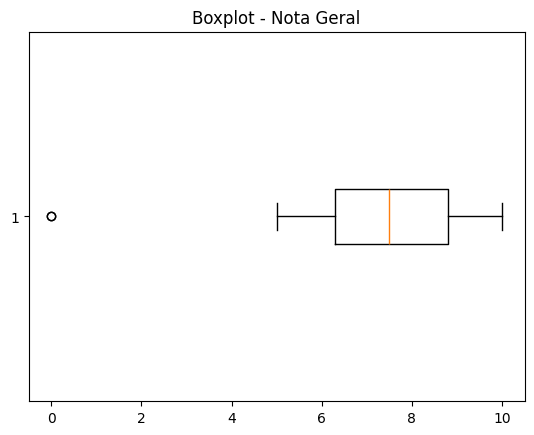

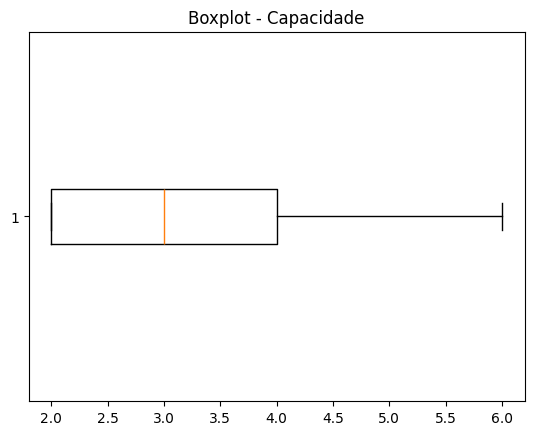

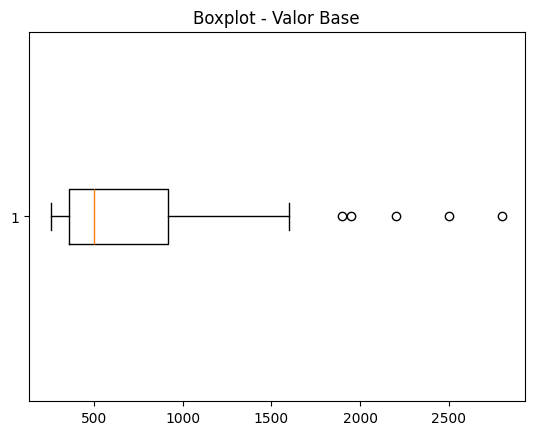

In [70]:
plt.figure()
plt.boxplot(array_nota, vert= False)
plt.title("Boxplot - Nota Geral")
plt.show()

plt.figure()
plt.boxplot(array_capacidade, vert= False)
plt.title("Boxplot - Capacidade")
plt.show()

plt.figure()
plt.boxplot(array_valor_base, vert= False)
plt.title("Boxplot - Valor Base")
plt.show()

In [71]:
print(reservas['valor_diaria'].head())

0   2344.25
1    469.17
2   2358.47
3   1743.13
4    617.85
Name: valor_diaria, dtype: float64
